# Review qualitative event candidates

Run this notebook after the `qualevents` Slurm job finishes. It displays the observation-only top candidates for the three qualitative regimes. Choose one event per regime, then save those rows to `qualitative_selected_events.csv`.


,category,t_start,start_time,p99_future_rain_mm_h,mean_fraction_above_1,mean_fraction_above_10,structural_change_mm_h,centroid_displacement_px
0,intense convection,168627,1533816900000000000,14.898438,0.134342,0.011085,1.498801,61.369725
1,widespread organized rainfall,98892,1512896400000000000,6.761719,0.218030,0.001828,1.104337,74.831814
2,rapidly evolving rainfall,99180,1512982800000000000,7.601562,0.172205,0.002855,1.059990,61.714830


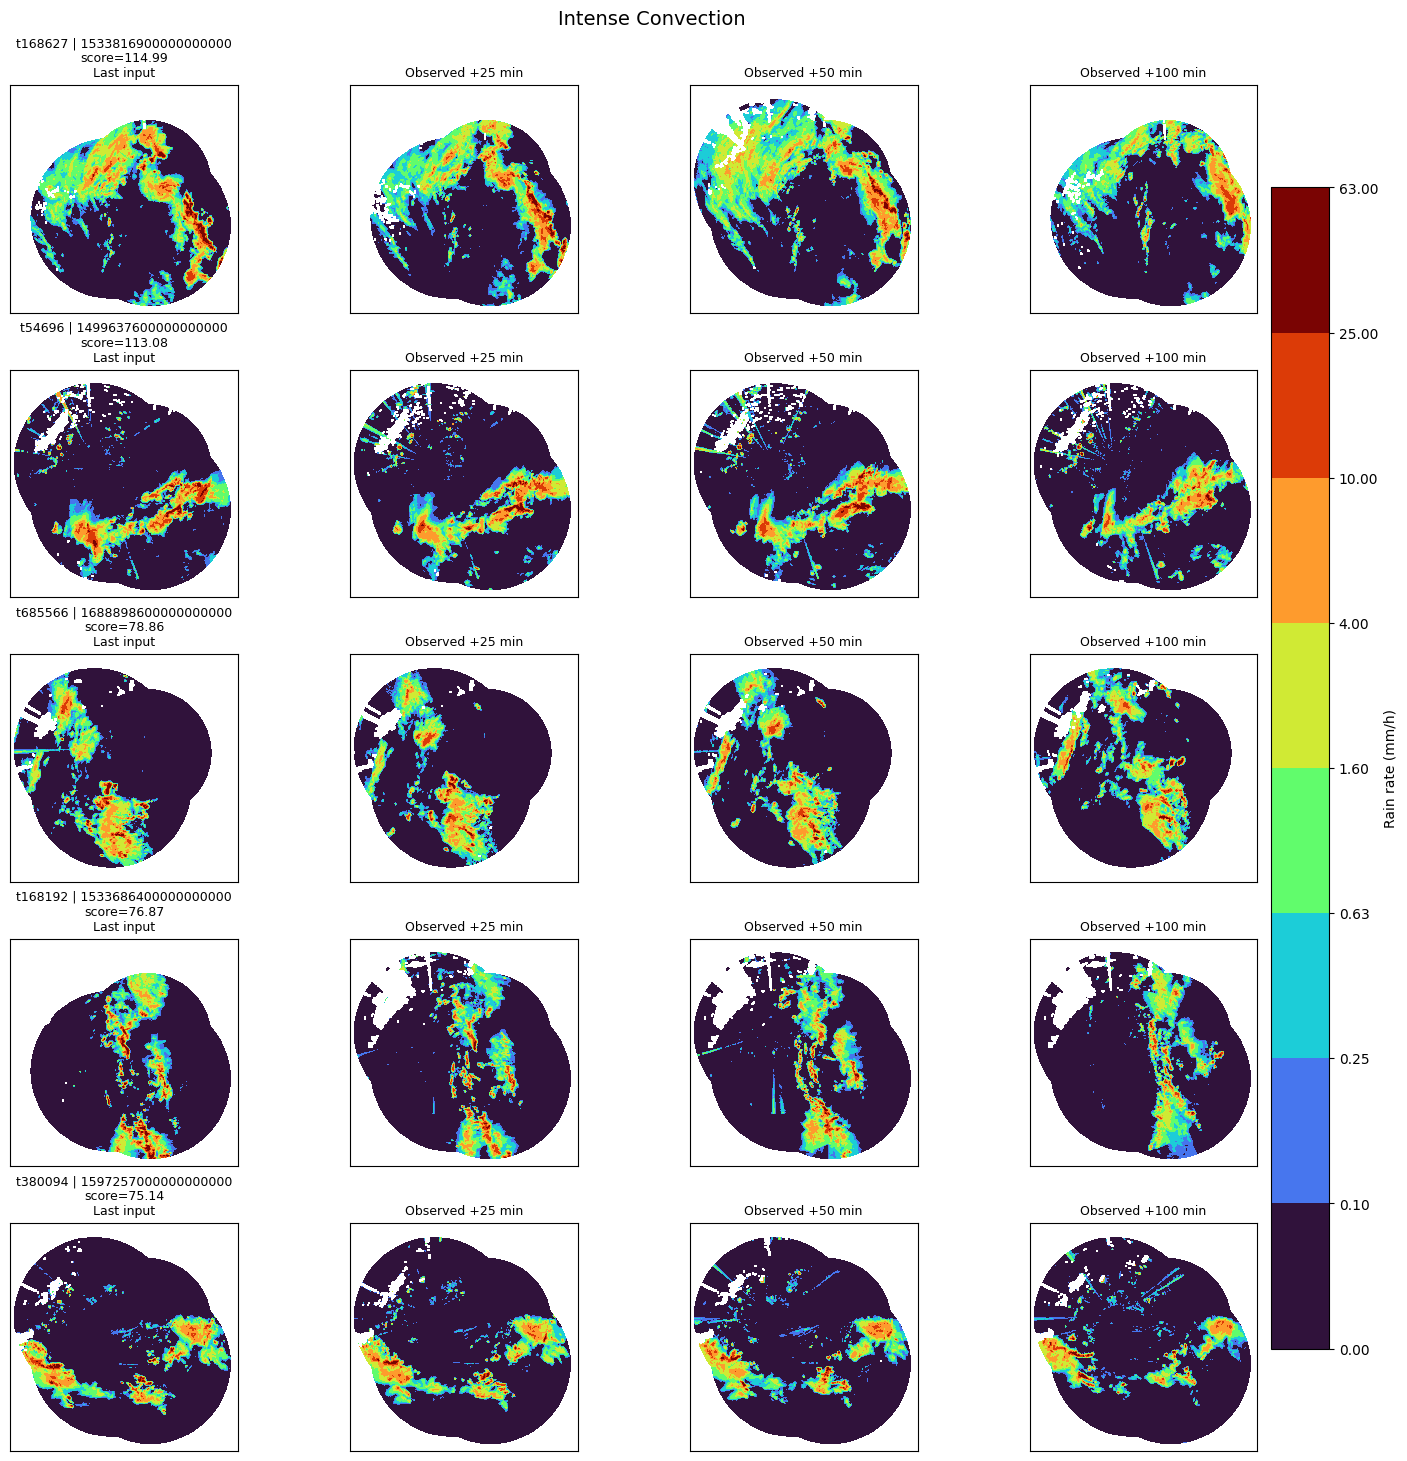

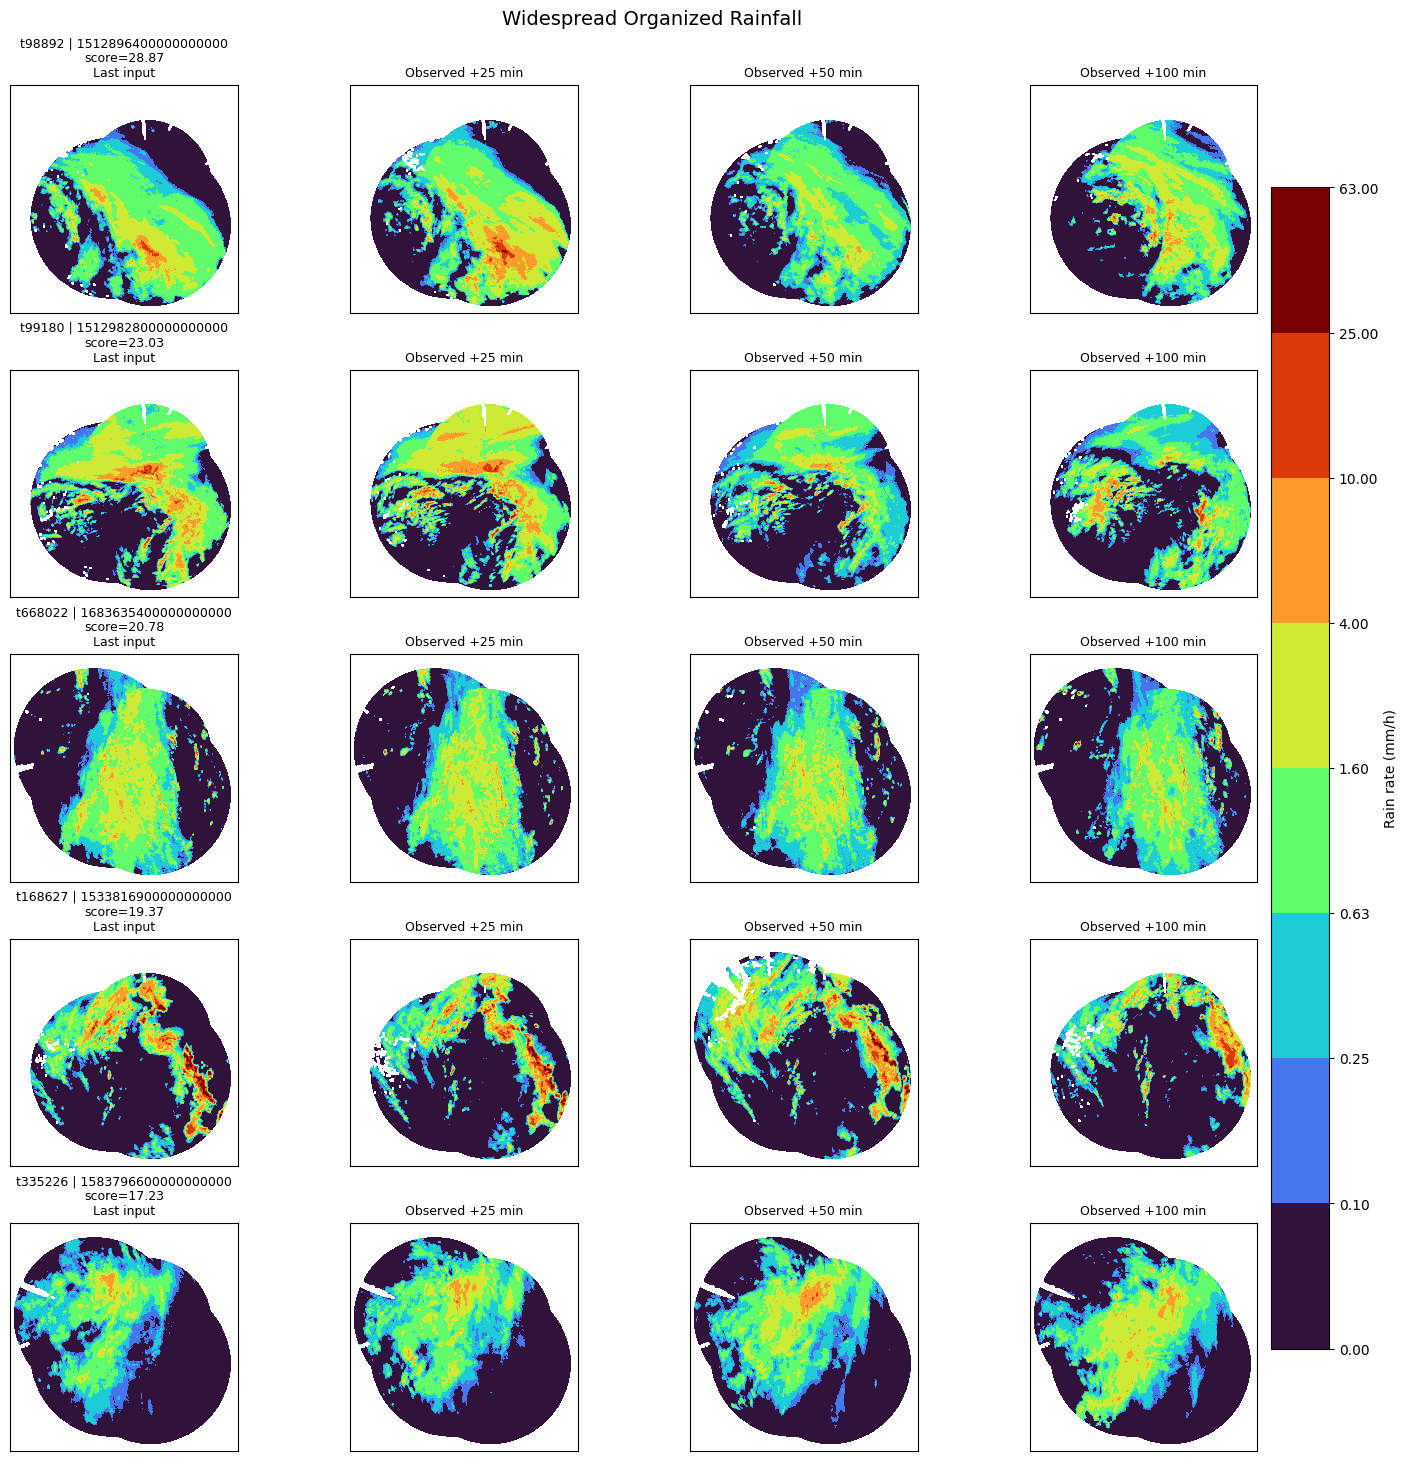

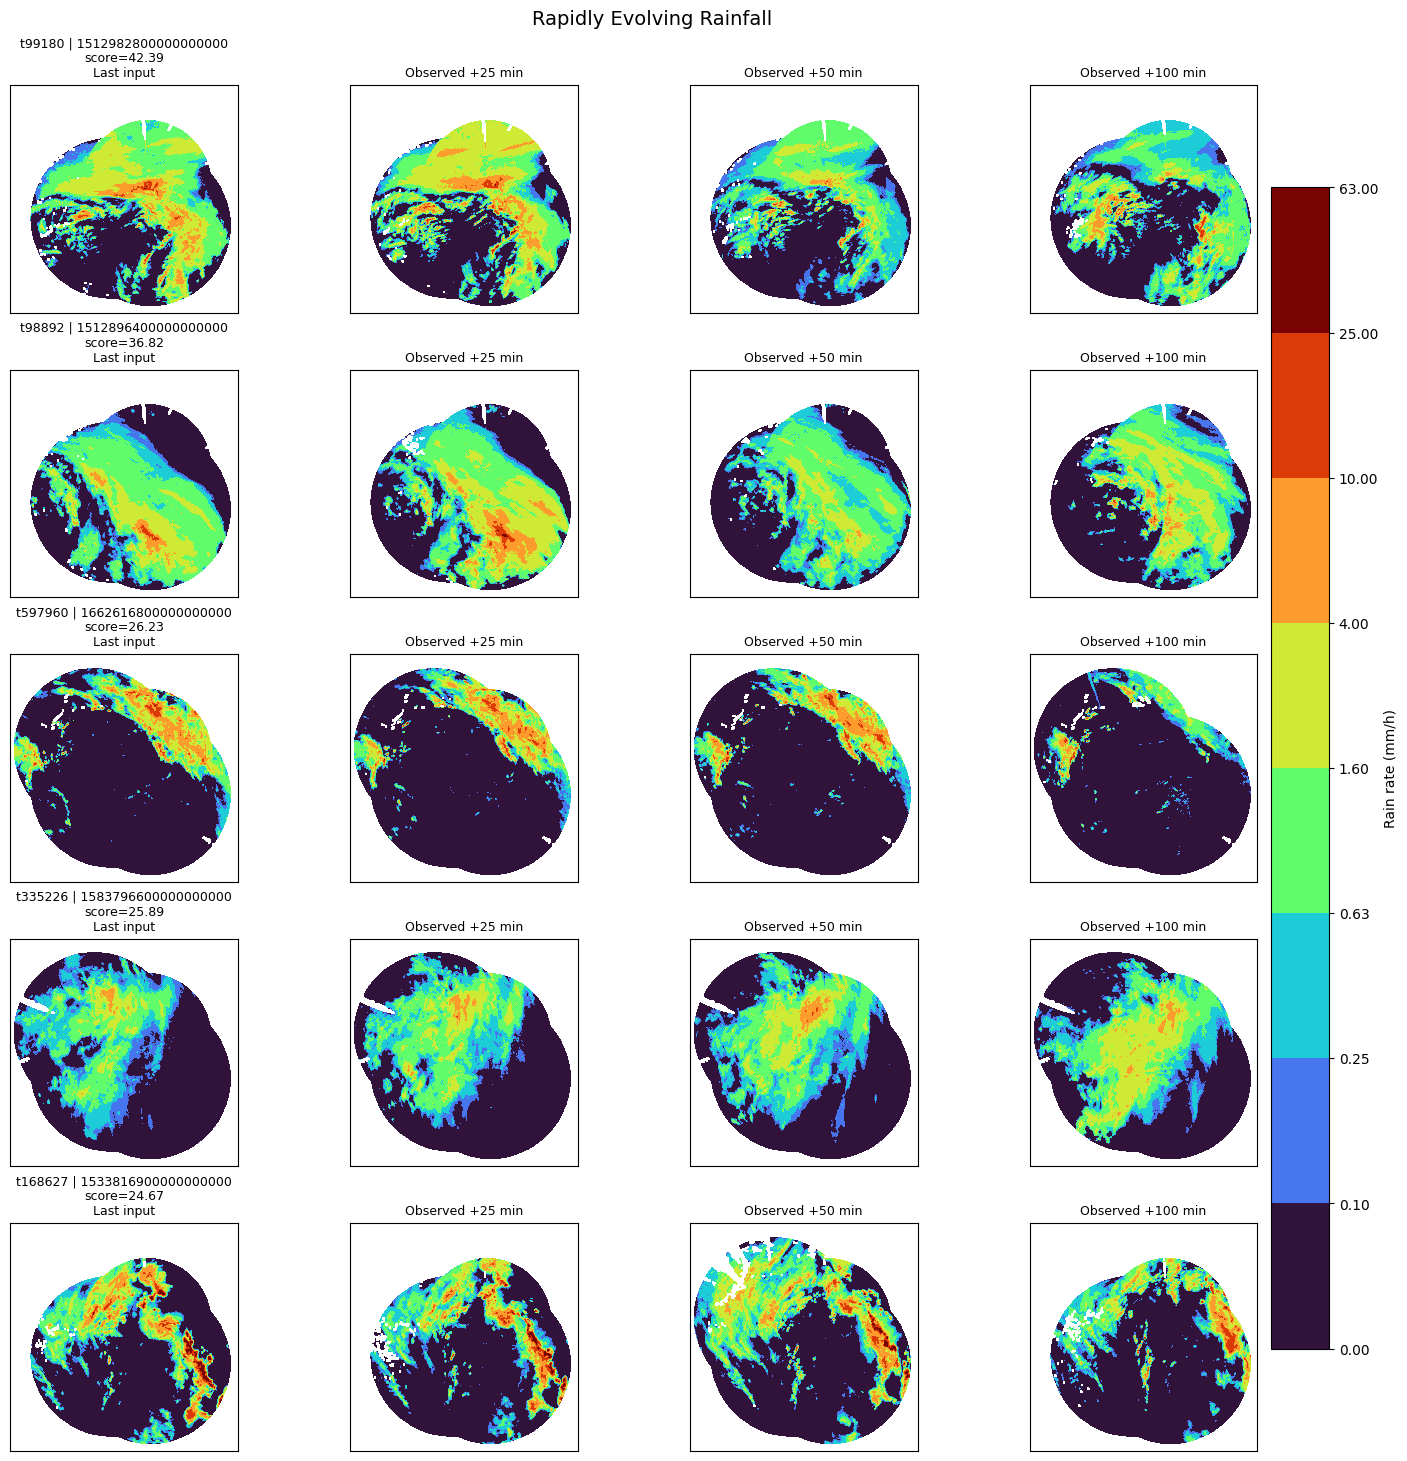

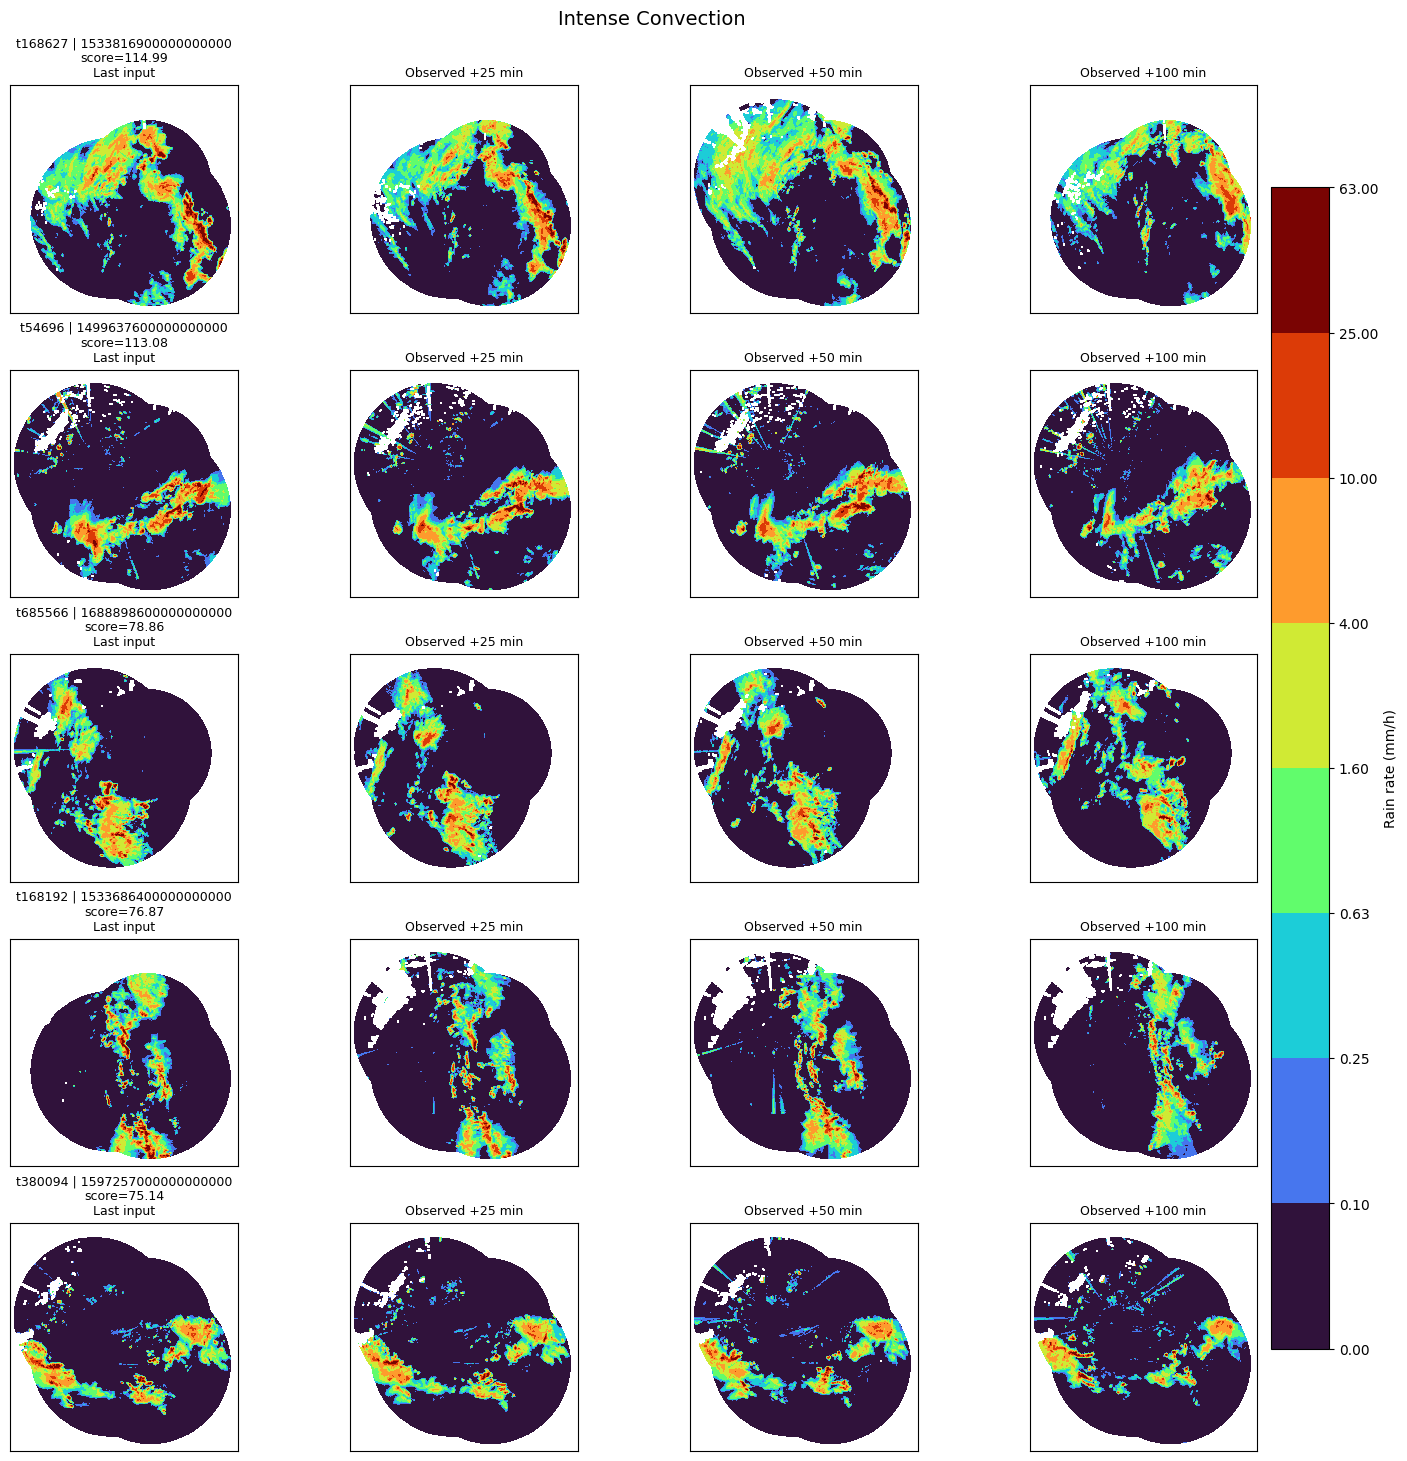

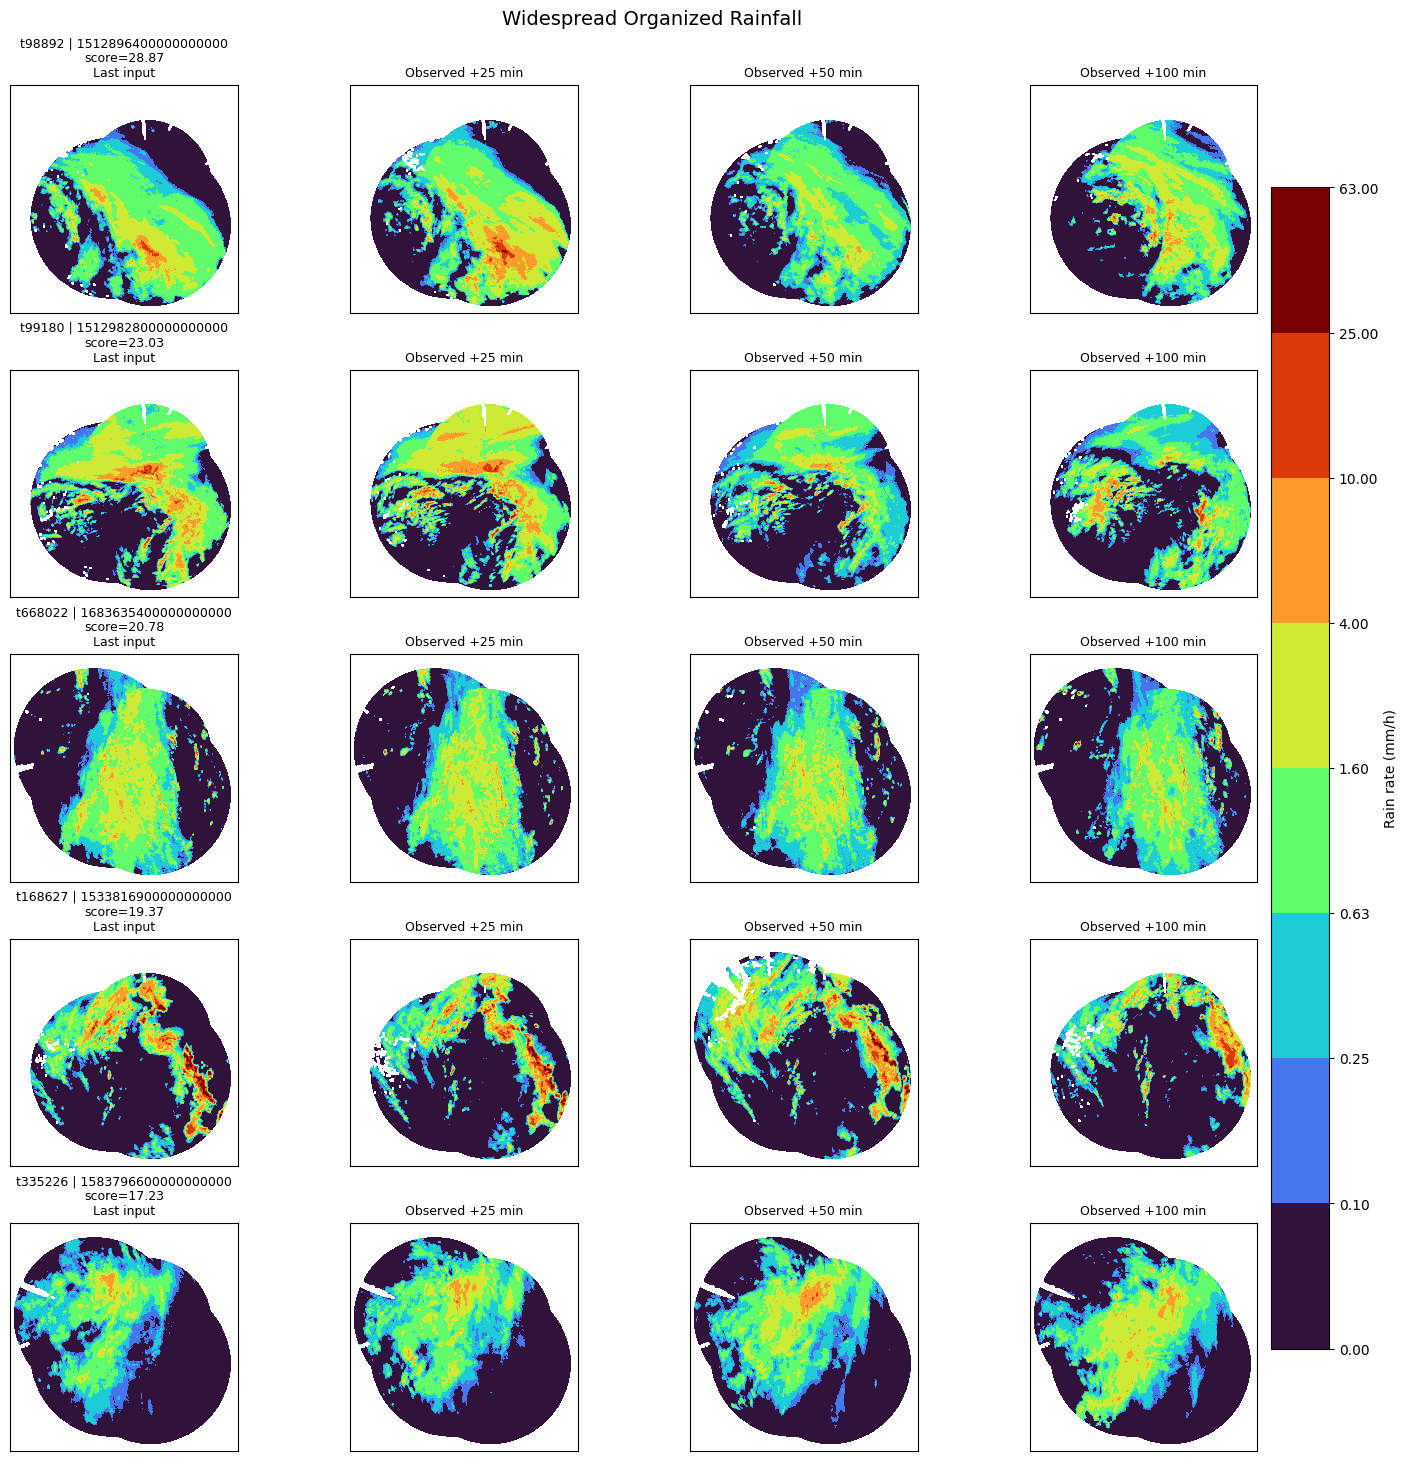

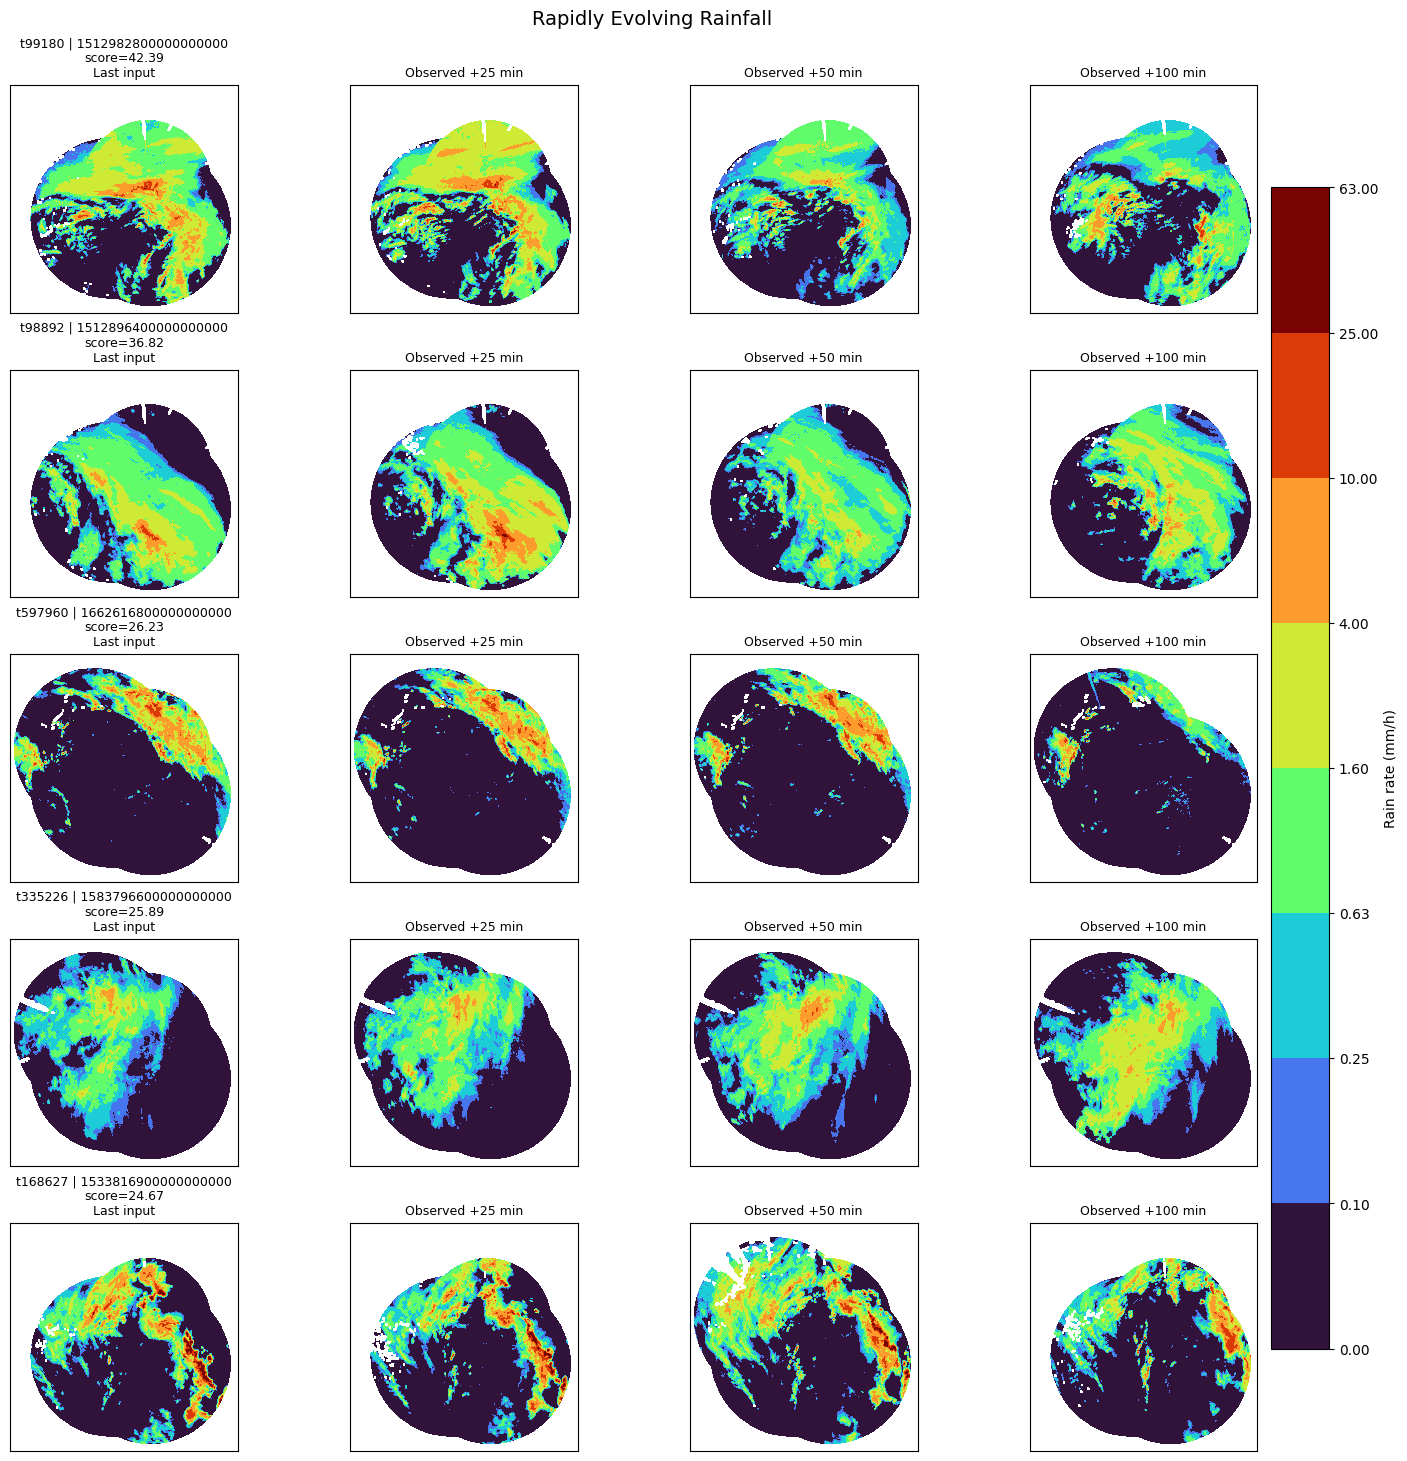

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
SELECTION_DIR = Path(
    "/data/brussel/114/vsc11442/code/mlcast-ldcast/"
    "results/evaluation/qualitative_event_selection"
)
TOP_FILE = SELECTION_DIR / "qualitative_top_candidates.csv"
SUGGESTED_FILE = SELECTION_DIR / "qualitative_suggested_events.csv"
SELECTED_FILE = SELECTION_DIR / "qualitative_selected_events.csv"

ZARR_PATH = (
    "/data/brussel/vo/000/bvo00029/data/observations/"
    "RADCLIMrates_2017_2023_5m_be_v1/RADCLIMrates_f16.zarr"
)
VAR_NAME = "precip_intensity_EDK"
TIN = 4
TOUT = 20
LEAD_INDICES = [4, 9, 19]  # +25, +50, +100 min

top = pd.read_csv(TOP_FILE)
suggested = pd.read_csv(SUGGESTED_FILE)

display(suggested[
    [
        "category",
        "t_start",
        "start_time",
        "p99_future_rain_mm_h",
        "mean_fraction_above_1",
        "mean_fraction_above_10",
        "structural_change_mm_h",
        "centroid_displacement_px",
    ]
])

ds = xr.open_zarr(ZARR_PATH)
da = ds[VAR_NAME]
time_dim = "time" if "time" in da.dims else da.dims[0]

BOUNDS = [0, 0.1, 0.25, 0.63, 1.6, 4, 10, 25, 63]
cmap = plt.get_cmap("turbo").copy()
cmap.set_under("white")
cmap.set_bad("white")
norm = mcolors.BoundaryNorm(BOUNDS, cmap.N)

def load_sequence(t_start):
    return np.asarray(
        da.isel({time_dim: slice(int(t_start), int(t_start) + TIN + TOUT)}).values,
        dtype=np.float32,
    )

def plot_category_candidates(category, n=5):
    rows = (
        top[top["category"] == category]
        .sort_values("category_score", ascending=False)
        .head(n)
    )

    fig, axes = plt.subplots(
        len(rows),
        1 + len(LEAD_INDICES),
        figsize=(15, 2.9 * len(rows)),
        constrained_layout=True,
    )
    axes = np.asarray(axes)
    if axes.ndim == 1:
        axes = axes.reshape(1, -1)

    im = None
    for r, row in enumerate(rows.itertuples()):
        seq = load_sequence(row.t_start)
        past = seq[:TIN]
        future = seq[TIN:TIN + TOUT]

        title_prefix = (
            f"t{int(row.t_start)} | {row.start_time}\n"
            f"score={row.category_score:.2f}"
        )

        im = axes[r, 0].imshow(past[-1], cmap=cmap, norm=norm)
        axes[r, 0].set_title(f"{title_prefix}\nLast input", fontsize=9)
        axes[r, 0].set_xticks([])
        axes[r, 0].set_yticks([])

        for c, lead_idx in enumerate(LEAD_INDICES, start=1):
            lead = (lead_idx + 1) * 5
            im = axes[r, c].imshow(future[lead_idx], cmap=cmap, norm=norm)
            axes[r, c].set_title(f"Observed +{lead} min", fontsize=9)
            axes[r, c].set_xticks([])
            axes[r, c].set_yticks([])

    cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
    cbar.set_label("Rain rate (mm/h)")
    fig.suptitle(category.title(), fontsize=14)
    plt.show()

for category in [
    "intense convection",
    "widespread organized rainfall",
    "rapidly evolving rainfall",
]:
    plot_category_candidates(category, n=5)


## Save the final reviewed selection

Replace the three numbers below with the selected `t_start` values after reviewing the plots.


In [4]:
FINAL_T_STARTS = {
    "intense convection": int(
        suggested.loc[
            suggested["category"] == "intense convection",
            "t_start",
        ].iloc[0]
    ),
    "widespread organized rainfall": int(
        suggested.loc[
            suggested["category"] == "widespread organized rainfall",
            "t_start",
        ].iloc[0]
    ),
    "rapidly evolving rainfall": int(
        suggested.loc[
            suggested["category"] == "rapidly evolving rainfall",
            "t_start",
        ].iloc[0]
    ),
}

selected_rows = []
descriptors = pd.read_csv(
    SELECTION_DIR / "qualitative_event_descriptors.csv"
)

for category, t_start in FINAL_T_STARTS.items():
    row = descriptors[descriptors["t_start"] == int(t_start)]
    if len(row) != 1:
        raise ValueError(
            f"Expected one descriptor row for t_start={t_start}, "
            f"found {len(row)}"
        )
    out = row.iloc[0].to_dict()
    out["category"] = category
    selected_rows.append(out)

selected = pd.DataFrame(selected_rows)
selected.to_csv(SELECTED_FILE, index=False)

print("Saved:", SELECTED_FILE)
display(selected[
    [
        "category",
        "t_start",
        "start_time",
        "p99_future_rain_mm_h",
        "mean_fraction_above_1",
        "mean_fraction_above_10",
        "structural_change_mm_h",
        "centroid_displacement_px",
    ]
])


Saved: /data/brussel/114/vsc11442/code/mlcast-ldcast/results/evaluation/qualitative_event_selection/qualitative_selected_events.csv


,category,t_start,start_time,p99_future_rain_mm_h,mean_fraction_above_1,mean_fraction_above_10,structural_change_mm_h,centroid_displacement_px
0,intense convection,168627.0,1.533817e+18,14.898438,0.134342,0.011085,1.498801,61.369725
1,widespread organized rainfall,98892.0,1.512896e+18,6.761719,0.218030,0.001828,1.104337,74.831814
2,rapidly evolving rainfall,99180.0,1.512983e+18,7.601562,0.172205,0.002855,1.059990,61.714830
